In [1]:
1

1

In [47]:
import pandas as pd
import glob
import duckdb
import tqdm
from pathlib import Path


# Reading in paths

In [3]:
con = duckdb.connect(database=':memory:')

In [4]:
def concat_tsvs(file_paths, table_name):
    """
    Concatenate TSV files and add metadata columns: source_path, rep, time,
    saving the result directly as a DuckDB table and previewing the first few rows.
    
    Parameters:
        file_paths (list of str): List of TSV file paths.
        table_name (str): Name of the DuckDB table to create.
        db_path (str): DuckDB database path (default is in-memory).
    
    Returns:
        duckdb.DuckDBPyConnection: Connection object to query the table further.
    """
    

    union_queries = []

    for path in file_paths:
        fname = Path(path).name  # just the filename, not full path
        # SQL to read TSV and extract rep/time
        union_queries.append(f"""
            SELECT *, 
                   SPLIT_PART('{fname}', '_', 2)::INTEGER AS rep,
                   SPLIT_PART('{fname}', '_', 3)::INTEGER AS time
            FROM read_csv_auto('{path}', sep='\t')
        """)

    query = " UNION ALL ".join(union_queries)

    # Create the table in DuckDB
    con.execute(f"CREATE OR REPLACE TABLE {table_name} AS {query}")

    # Preview the first few rows
    display(con.execute(f"SELECT * FROM {table_name} LIMIT 5").df())

RPTR simple

In [5]:
RPTR_simple_umi_counts = glob.glob("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR*/*simple_umi_counts.tsv")
RPTR_simple_umi_counts[:3]

['/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR_2_10_S10_R1_001_fastp/RPTR_2_10_S10_R1_001_fastp_simple_umi_counts.tsv',
 '/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR_2_5_S9_R1_001_fastp/RPTR_2_5_S9_R1_001_fastp_simple_umi_counts.tsv',
 '/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR_3_10_S17_R1_001_fastp/RPTR_3_10_S17_R1_001_fastp_simple_umi_counts.tsv']

In [6]:
concat_tsvs(RPTR_simple_umi_counts, table_name='rptr_counts')

,RPTR_BC,count,rep,time
0,CATTCATAAAGAAC,57901,2,10
1,TGTATCCATCTACC,40725,2,10
2,CCAACGGTGTCGAA,39843,2,10
3,TACAACCGGCAAGG,36001,2,10
4,TGCATCTAGATAAA,33264,2,10


In [7]:
con.execute("""
    SELECT rep, COUNT(*) AS n
    FROM rptr_counts
    GROUP BY rep
    ORDER BY rep
""").df()

,rep,n
0,1,17027431
1,2,17417579
2,3,15858193


In [8]:
con.execute("""
    SELECT time, COUNT(*) AS n
    FROM rptr_counts
    GROUP BY time
    ORDER BY time
""").df()

,time,n
0,0,4268613
1,5,4918491
2,10,7274572
3,15,8018542
4,30,7445241
5,180,9074504
6,240,9303240


AD simple

In [9]:
AD_simple_umi_counts = glob.glob("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_AD*/*simple_umi_counts.tsv")
AD_simple_umi_counts[:3]

['/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_AD_1_0/AD_1_0_simple_umi_counts.tsv',
 '/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_AD_3_30/AD_3_30_simple_umi_counts.tsv',
 '/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_AD_1_15/AD_1_15_simple_umi_counts.tsv']

In [10]:
concat_tsvs(AD_simple_umi_counts, table_name='ad_counts')

,AD,AD_BC,count,rep,time
0,CCATCTGACTTTCCATTTCCAGAAACTTTGACTTCTTCTACTGCTT...,TTATTCGAATT,15006,1,0
1,TCTTCTTCATTTGGTTTGTCTGGTAATTCTTCTCAACATAGATTGT...,CGCGGCTACAA,9399,1,0
2,TTTCCACCATCTTCTCCATCTATGACTACTGAAATGGTTTCTTTGC...,AGTAACAGCTG,9337,1,0
3,AGACCAGCTAGACCACCAGTTCCATTGTTCTCTCAATCTACTGGTT...,TCCTAAGCTCG,7397,1,0
4,AATACATTTCATTCTGCTTATTCTTCTCCAGCTGTTCCAACTTTGT...,ATACCGCCAAC,7359,1,0


In [11]:
con.execute("""
    SELECT rep, COUNT(*) AS n
    FROM ad_counts
    GROUP BY rep
    ORDER BY rep
""").df()

,rep,n
0,1,1431597
1,2,1482919
2,3,1435683


In [12]:
con.execute("""
    SELECT time, COUNT(*) AS n
    FROM ad_counts
    GROUP BY time
    ORDER BY time
""").df()

,time,n
0,0,622561
1,5,616450
2,10,640323
3,15,606610
4,30,608226
5,180,608439
6,240,647590


# Recalculate activity scores

In [13]:
step1_path = "../../output/GCN4/step1_AD_AD_BC_RPTR_BC_designed.csv"
pd.read_csv(step1_path)

,AD,AD_BC,RPTR_BC,count,AD_qual,AD_BC_qual,RPTR_BC_qual,Designed
0,CCATTGTGTTCTCCTAAAGCTCCATCTGCTTTGATTACTCCAATGA...,AAAGTTATCAA,TTCGGTGCCATAAC,87,True,True,True,1
1,TTTGATCCATCTAATGAAATTTCATTTGATGATCCAGTCTTGTTTC...,CAGTAACTATC,ATACGACGCTTTAC,87,True,True,True,1
2,TCTTCTTCTGTTCCATCTTCTGTTTCTAATATGGGTACTGTTTCTC...,GACCCCAACGT,CACCACGCTTAGCT,87,True,True,True,1
3,CCAACTTCTACTGCTACTACTAATTTGGCTTCTCCATTGTCTTTGT...,GGATCCAAGTT,ATGCGTATTATTTA,87,True,True,True,1
4,GCTGCTCATTACTTCTTGGCTTTGAGACAATCTCAAGAGTTCTCTG...,TCACTTGTTAT,CGAATGACTCGACC,87,True,True,True,1
...,...,...,...,...,...,...,...,...
127403,ACTGCTTTGACTTCTCCATCTTTGTATGATGAATCTCCAGACTTTG...,CCTTCCCGCAG,TCGCAATTTCCTCT,87,True,True,True,1
127404,GTTGCTAATATGGCTGATTTAAATTCTAATAATTCATTTGATTCTG...,TTCACTCCTTA,CACGCAAGCCAAGG,87,True,True,True,1
127405,GCATTTACTAATTTGACTTCTCCATCTACTTATAATGAATCTCCAG...,CTCGGCAGAAG,TAACCCCAACACCG,87,True,True,True,1
127406,AATGCTTCTTCTGCTCCATCTTCTTCTTCATTTGGTTTGTCTGGTA...,TAAGAAACGAC,GAGGACAATCATCG,87,True,True,True,1


In [14]:
# Registering step 1 map in the duckdb file
con.execute(f"""
    CREATE OR REPLACE TABLE step1_map AS
    SELECT * FROM read_csv_auto('{step1_path}', sep=',')
""")
con.execute(f"""
    CREATE OR REPLACE TABLE step1_map AS
    SELECT AD, AD_BC, RPTR_BC
    FROM read_csv_auto('{step1_path}', sep=',');
    SELECT * FROM step1_map LIMIT 5;
""").fetchdf()

,AD,AD_BC,RPTR_BC
0,CCATTGTGTTCTCCTAAAGCTCCATCTGCTTTGATTACTCCAATGA...,AAAGTTATCAA,TTCGGTGCCATAAC
1,TTTGATCCATCTAATGAAATTTCATTTGATGATCCAGTCTTGTTTC...,CAGTAACTATC,ATACGACGCTTTAC
2,TCTTCTTCTGTTCCATCTTCTGTTTCTAATATGGGTACTGTTTCTC...,GACCCCAACGT,CACCACGCTTAGCT
3,CCAACTTCTACTGCTACTACTAATTTGGCTTCTCCATTGTCTTTGT...,GGATCCAAGTT,ATGCGTATTATTTA
4,GCTGCTCATTACTTCTTGGCTTTGAGACAATCTCAAGAGTTCTCTG...,TCACTTGTTAT,CGAATGACTCGACC


In [15]:
# rptr_merged

con.execute(f"""
    CREATE OR REPLACE TABLE rptr_merged AS
    SELECT s.*, r.count as RT_umi_count, r.rep, r.time 
    FROM step1_map s
    INNER JOIN rptr_counts r
    ON r.RPTR_BC = s.RPTR_BC;
    SELECT * FROM rptr_merged LIMIT 5;
""").fetchdf()

,AD,AD_BC,RPTR_BC,RT_umi_count,rep,time
0,TTCTTCTCTTCTTCTGTTGATTCTACTCCAATGTTTGATTTGGATG...,CCCCACCGGCC,CATTCATAAAGAAC,62594,1,15
1,CAGAATGCTTCTCCAATGTTTACTGATATGGATTTGGTTGGTCATG...,ACTTCTGTCCC,TACAACCGGCAAGG,36697,1,15
2,GATGCTGTTGTTGAATCATTCTTCTCTTCTTCTACTGATTCTACTC...,GCGCGGACCAC,CCAACGGTGTCGAA,35160,1,15
3,TATTCTGATGGTCCATCTTCTTCTGGATTTGTTTCTAATTTGGGTT...,TTTTTGATCCG,GCACGACCTCAAGA,30907,1,15
4,TTGACTTCTCCAGATATTGATGCTTCTCCATTTATTAATGATTCAT...,ACCGCCTCGGC,ATACCCGAACGAGT,28348,1,15


In [16]:
con.execute("""
    SELECT time, COUNT(*) AS n
    FROM rptr_merged
    GROUP BY time
    ORDER BY time
""").df()

,time,n
0,0,43953
1,5,44597
2,10,45842
3,15,46073
4,30,45896
5,180,47354
6,240,47698


In [17]:
con.execute("""
    SELECT rep, COUNT(*) AS n
    FROM rptr_merged
    GROUP BY rep
    ORDER BY rep
""").df()

,rep,n
0,1,107142
1,2,107296
2,3,106975


In [18]:
# ad_merged

con.execute(f"""
    CREATE OR REPLACE TABLE ad_merged AS
    SELECT s.*, a.count as AD_umi_count, a.rep, a.time 
    FROM step1_map s
    INNER JOIN ad_counts a
    ON a.AD_BC = s.AD_BC AND a.AD = s.AD;
    SELECT * FROM ad_merged LIMIT 5;
""").fetchdf()

,AD,AD_BC,RPTR_BC,AD_umi_count,rep,time
0,TCATTTGAAACTTCTCCATTGTTTGCTAATGCTGATCATGATTTGG...,GGCCACAAGAC,CCTCTATGAAACCA,1,2,30
1,TTGCCAACTCCACCACAACCAATTGTTAATGATTTGACTGTTGCTC...,CCTTCGCCAAA,TTGTTCGCATTAGT,1,2,30
2,GCTGAGAAATCTGATGATTTGGAAGTTGTTGAACCAACTTCTGGTC...,TCACTTGTGCT,TGATAGGGACCCGC,1,2,30
3,ATTCAGAATCCAAGAGTTTCTGATTTGTCTCAAGATACTGGTTCTA...,CGGTGCCTTAA,AGCCGTAAAGCTAA,1,2,30
4,CAGAATACTCAGAAATATAGAAGAGTTATGTCTACTCCAAACTTTA...,CTTAATATTCC,ATGTCCAGCAAGCG,1,2,30


In [19]:
# Outer join AD and RT umi counts
con.execute("""
    CREATE OR REPLACE TABLE ad_rptr_merged AS
    SELECT a.AD,
        a.AD_BC,
        a.RPTR_BC,
        a.rep,
        a.time,
        a.AD_umi_count,
        r.RT_umi_count
    FROM rptr_merged r
    INNER JOIN ad_merged a
    ON a.AD_BC = r.AD_BC 
       AND a.AD = r.AD 
       AND a.RPTR_BC = r.RPTR_BC
       AND a.rep = r.rep
       AND a.time = r.time
""")

# Step 2: Preview the first 5 rows
con.execute("SELECT * FROM ad_rptr_merged LIMIT 5").df()

,AD,AD_BC,RPTR_BC,rep,time,AD_umi_count,RT_umi_count
0,GCTTCTGGTTCTACTAGAACTGTTTCTCCTAAAGATATCTTTGCTG...,ATAATGTCTGC,TTTGTCACTCGCAA,3,180,114,8
1,AGAAGACAGAAGACTTCTAGAGTTAGAGTTTATAGACCAGGTGCTT...,AGTTGAGCGGT,TTGACGTGGCCTGA,3,180,114,74
2,GCTAGAAATACTTTGGCTGCTAGGAAATCTAGACAAAGGAAGATGC...,CGACCCTGTTC,TACTCGCCTTCCTC,3,180,114,105
3,TCTCATCAAGGTAGACATTCATTTACTTCTGGTGTTGCTCCTAAGA...,CTGGTTTCGAA,TCAGCTGTTACATG,3,180,114,86
4,CAACATCAACAATTGGAATCTACTTTGAGATCTTATAAGATGCAAC...,GTACCATAACA,TCCCAGACGTTTAT,3,180,114,434


In [20]:
# Collapsed RTBCs and calculated activities

# con.execute("""
#     CREATE OR REPLACE TABLE ad_rptr_summary AS
#     SELECT 
#         AD,
#         AD_BC,
#         rep, 
#         time,
#         AD_umi_count,
#         SUM(RT_umi_count) AS RT_umi_count_sum,
#         (RT_umi_count_sum + 1)/(AD_umi_count + 1) AS activity
#     FROM ad_rptr_merged
#     GROUP BY AD, AD_BC, AD_umi_count, rep, time
# """)

con.execute("""
    CREATE OR REPLACE TABLE ad_rptr_summary AS
    SELECT 
        *,
        (RT_umi_count)/(AD_umi_count) AS activity
    FROM ad_rptr_merged
""")

bc_activities = con.execute("SELECT * FROM ad_rptr_summary").df().dropna()
bc_activities

,AD,AD_BC,RPTR_BC,rep,time,AD_umi_count,RT_umi_count,activity
0,GCTTCTGGTTCTACTAGAACTGTTTCTCCTAAAGATATCTTTGCTG...,ATAATGTCTGC,TTTGTCACTCGCAA,3,180,114,8,0.070175
1,AGAAGACAGAAGACTTCTAGAGTTAGAGTTTATAGACCAGGTGCTT...,AGTTGAGCGGT,TTGACGTGGCCTGA,3,180,114,74,0.649123
2,GCTAGAAATACTTTGGCTGCTAGGAAATCTAGACAAAGGAAGATGC...,CGACCCTGTTC,TACTCGCCTTCCTC,3,180,114,105,0.921053
3,TCTCATCAAGGTAGACATTCATTTACTTCTGGTGTTGCTCCTAAGA...,CTGGTTTCGAA,TCAGCTGTTACATG,3,180,114,86,0.754386
4,CAACATCAACAATTGGAATCTACTTTGAGATCTTATAAGATGCAAC...,GTACCATAACA,TCCCAGACGTTTAT,3,180,114,434,3.807018
...,...,...,...,...,...,...,...,...
301121,GATTCTCCAGGTTACTTCTCTCAAGAAACTTCTCCAATGTTTCCAG...,TACTTGAACAT,CATAGACGTCGGCA,3,15,119,1303,10.949580
301122,TTGTTGCAAGATTCATTTATGTCTGCTCCAAATTCTGCTGCTTTGA...,CCCCACACTTG,CTGGTCCTTTGCAA,3,15,119,53,0.445378
301123,TCTTCTTCTGCTGCTTTGAATAGAAGACAAAGACCACCAGTTCCAT...,ACTTCCTAGCG,TACAGCCCCCACCC,3,15,119,65,0.546218
301124,CAAGCTTCTGGTTCTCATTCTAGACCATCTTCTGTTTATTCTCCAG...,GAGACTGACAG,TTCAAGTTGAGCTA,3,15,119,42,0.352941


In [21]:
# Calculating activities and standard deviaiton per AD
con.execute("""
    CREATE OR REPLACE TABLE ad_activities AS
    SELECT 
        AD,
        rep, 
        time,
        AVG(activity) AS activity_avg,
        stddev_samp(activity) AS activity_std,
    FROM ad_rptr_summary
    GROUP BY AD, rep, time
""")

activities = con.execute("SELECT * FROM ad_activities").df()
activities

,AD,rep,time,activity_avg,activity_std
0,TCTGTTCCAATCTTCTCTGAATCTAAGAGATCTACTGATTTGGATT...,3,240,1136.333333,1111.420862
1,GAATCTCCATATATTGATGATTTGTATGATACTTCTCCAATGTTTA...,3,240,298.000000,NaN
2,ACTATGTCTCCAGATATGTTGGATATGCAAAATTCTCCAGTTGACT...,3,240,1787.500000,1863.226368
3,TTTGCTAATGCTGATGCTGATTTGGCTGGTCAAGATGCTTGGTTCT...,3,240,2605.000000,NaN
4,ATGTTGGATGCTTCTGCTCCATCTTCTGCTACATTTACTGATTTGT...,3,240,1465.500000,1386.636398
...,...,...,...,...,...
210659,GTTTCTCCACATGATTTGTTGATTAGAGAACCATTTGCTTCTGCTC...,2,15,798.000000,NaN
210660,CCATCTTCTGATATGTTGTTTGATTTGGGTGACTTTCCAGCTTCTC...,2,15,1824.000000,NaN
210661,GAAGCTGCATTTGCTTCTCCAGCTAATCAAACTTATGATTTGTCTT...,2,15,3492.500000,3786.556813
210662,AAATCTGATGATTTGGAAGTTGTTGAACCAACTTCTGGTCATCAAA...,2,15,85.333333,47.226405


In [22]:
activities = activities.dropna(subset = "AD")
activities

,AD,rep,time,activity_avg,activity_std
0,TCTGTTCCAATCTTCTCTGAATCTAAGAGATCTACTGATTTGGATT...,3,240,1136.333333,1111.420862
1,GAATCTCCATATATTGATGATTTGTATGATACTTCTCCAATGTTTA...,3,240,298.000000,NaN
2,ACTATGTCTCCAGATATGTTGGATATGCAAAATTCTCCAGTTGACT...,3,240,1787.500000,1863.226368
3,TTTGCTAATGCTGATGCTGATTTGGCTGGTCAAGATGCTTGGTTCT...,3,240,2605.000000,NaN
4,ATGTTGGATGCTTCTGCTCCATCTTCTGCTACATTTACTGATTTGT...,3,240,1465.500000,1386.636398
...,...,...,...,...,...
210659,GTTTCTCCACATGATTTGTTGATTAGAGAACCATTTGCTTCTGCTC...,2,15,798.000000,NaN
210660,CCATCTTCTGATATGTTGTTTGATTTGGGTGACTTTCCAGCTTCTC...,2,15,1824.000000,NaN
210661,GAAGCTGCATTTGCTTCTCCAGCTAATCAAACTTATGATTTGTCTT...,2,15,3492.500000,3786.556813
210662,AAATCTGATGATTTGGAAGTTGTTGAACCAACTTCTGGTCATCAAA...,2,15,85.333333,47.226405


In [23]:
# About half are nulls
sum(activities["activity_std"].isna())

142966

In [24]:
activities_pivot = pd.pivot(activities, index = ["AD", "rep"], columns = ["time"], values = ["activity_avg"])
activities_pivot

activity_avg  \
time                                                            0     
AD                                                 rep                
AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATGA... 1       0.246753   
                                                   2       0.182796   
                                                   3       0.205993   
AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTAA... 1       0.211343   
                                                   2       0.242637   
...                                                             ...   
TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTAC... 2       0.125940   
                                                   3       0.064246   
TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTGC... 1      11.000000   
                                                   2      29.000000   
                                                   3      61.000000   

                                                                    \
time                                                           5     
AD                                                 rep               
AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATGA... 1      0.179856   
                                                   2      0.100279   
                                                   3      0.132743   
AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTAA... 1      0.259402   
                                                   2      0.211889   
...                                                            ...   
TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTAC... 2      0.081571   
                                                   3      0.073482   
TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTGC... 1    102.000000   
                                                   2    130.000000   
                                                   3    121.000000   

                                                                    \
time                                                           10    
AD                                                 rep               
AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATGA... 1      0.137255   
                                                   2      0.123626   
                                                   3      0.119874   
AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTAA... 1      0.256198   
                                                   2      0.219101   
...                                                            ...   
TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTAC... 2      0.033573   
                                                   3      0.080488   
TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTGC... 1    168.000000   
                                                   2    148.000000   
                                                   3    225.000000   

                                                                    \
time                                                           15    
AD                                                 rep               
AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATGA... 1      0.167665   
                                                   2      0.167147   
                                                   3      0.261682   
AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTAA... 1      0.178448   
                                                   2      0.187410   
...                                                            ...   
TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTAC... 2      0.074074   
                                                   3      0.025862   
TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTGC... 1    208.000000   
                                                   2    343.000000   
                                                   3    279.000000   

                                                                    \
time                                           

In [25]:
std_pivot = pd.pivot(activities, index = ["AD", "rep"], columns = ["time"], values = ["activity_std"])
std_pivot

activity_std            \
time                                                            0         5     
AD                                                 rep                          
AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATGA... 1            NaN       NaN   
                                                   2            NaN       NaN   
                                                   3            NaN       NaN   
AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTAA... 1       0.103126  0.174547   
                                                   2       0.298216  0.173487   
...                                                             ...       ...   
TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTAC... 2            NaN       NaN   
                                                   3            NaN       NaN   
TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTGC... 1            NaN       NaN   
                                                   2            NaN       NaN   
                                                   3            NaN       NaN   

                                                                            \
time                                                         10        15    
AD                                                 rep                       
AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATGA... 1         NaN       NaN   
                                                   2         NaN       NaN   
                                                   3         NaN       NaN   
AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTAA... 1    0.269096  0.173481   
                                                   2    0.190319  0.146869   
...                                                          ...       ...   
TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTAC... 2         NaN       NaN   
                                                   3         NaN       NaN   
TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTGC... 1         NaN       NaN   
                                                   2         NaN       NaN   
                                                   3         NaN       NaN   

                                                                            \
time                                                         30        180   
AD                                                 rep                       
AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATGA... 1         NaN       NaN   
                                                   2         NaN       NaN   
                                                   3         NaN       NaN   
AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTAA... 1    0.150907  0.798226   
                                                   2    0.188396  0.744245   
...                                                          ...       ...   
TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTAC... 2         NaN       NaN   
                                                   3         NaN       NaN   
TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTGC... 1         NaN       NaN   
                                                   2         NaN       NaN   
                                                   3         NaN       NaN   

                                                                  
time                                                         240  
AD                                                 rep            
AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATGA... 1         NaN  
                                                   2         NaN  
                                                   3         NaN  
AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTAA... 1    0.596294  
                                                   2    0.879288  
...                                                          ...  
TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTAC... 2         NaN  
                                                   3         NaN

# Compare to EC activity scores

In [26]:
# All activities from EC's demultixed UMI calcuations
EC_activities = pd.read_csv("../../from_EC/20250226_TREBL_MAZ06/demultiplexed_counts.csv")
EC_activities["Time"] = EC_activities["Library"].str.split("_").str[1]
EC_activities["sample"] = EC_activities["Library"].str.split("_").str[0]
EC_activities = EC_activities.rename(columns={"Ratio_negctrlnorm": "Ratio_negCTRLnorm",
    "UMIs_RPTR": "RPTR_UMIs",
    "UMIs_AD": "AD_UMIs"})
EC_activities = EC_activities[["AD", "AD_BC", "RPTR_BC", "sample", "Time", "AD_UMIs", "RPTR_UMIs"]]
EC_activities = EC_activities.rename(columns = {"sample" : "rep", 
                                                "Time" : "time", 
                                                "AD_UMIs" : "EC_AD_umi_count", 
                                                "RPTR_UMIs" : "EC_RT_umi_count"})
EC_activities["rep"] = EC_activities["rep"].astype(int)
EC_activities["time"] = EC_activities["time"].astype(int)
EC_activities["EC_activity"] = EC_activities["EC_RT_umi_count"] / EC_activities["EC_AD_umi_count"]
EC_activities

,AD,AD_BC,RPTR_BC,rep,time,EC_AD_umi_count,EC_RT_umi_count,EC_activity
0,GGTACTATTTCTCCTAAAGATTTGATGATGGATGCTTCTGTTCCAC...,ACTCGGAATTG,TATACATCCACCAT,3,5,646,402,0.622291
1,GATGCTTCTCCATTCTTGAATGAATCATTTGAAACTTCTCCAATGT...,CATCTAGGAAA,AAGTGGTGAGAAGC,3,5,806,2784,3.454094
2,TCATTTGAAACTTCTCCAATGTTTCAAGGTGAACCAATGTTAAATT...,TGGGAGCCCTT,GTACGAAGTCAGTG,3,5,657,1349,2.053272
3,ATGTTTACTGATTTGGATGTTGCTGGTCATGAAGATTGGCCATCTT...,AAGTTCTTTCA,CTATTCCGAAATAT,3,5,167,1012,6.059880
4,TTGGATTTGGATGACTTTACTGGATTTGAAGGTGGTGCTTCTACTA...,TCTTAGGCTCG,AAAGTTCTCAGACA,3,5,917,690,0.752454
...,...,...,...,...,...,...,...,...
347306,AATTTGTGGATGGGTTTGCATGGTCCTAAAGATCAAGAAGCTAGAG...,CGGGGTGTCTG,TTCAGAGAAAGCGC,1,240,57,13,0.228070
347307,AGACATTCTTCTAATATTCCATCTGCTTCTTCTTTGCAGAATCAAA...,GAAAACTTTAA,AAATCAGGTGCGCT,1,240,53,3,0.056604
347308,TGTTCATTTAGATCTATTGAAAGAAATCAATTTAGAAGATCTTCTG...,CGCCAGGCGCT,AATAAATTGTTATG,1,240,313,1,0.003195
347309,TCTTTGTCTTTGGGTAAAGGTTGTGCTGGTGAATTGACTCCACCAC...,GCATGAGTTAG,ATAAAACTAGCCTG,1,240,536,1,0.001866


In [27]:
#SK_activities = bc_activities.drop(columns = ["AD_umi_count", "RT_umi_count"])
SK_activities = bc_activities.rename(columns = {"activity" : "SK_activity"})
SK_activities["rep"] = SK_activities["rep"].astype(int)
SK_activities["time"] = SK_activities["time"].astype(int)
SK_activities

,AD,AD_BC,RPTR_BC,rep,time,AD_umi_count,RT_umi_count,SK_activity
0,GCTTCTGGTTCTACTAGAACTGTTTCTCCTAAAGATATCTTTGCTG...,ATAATGTCTGC,TTTGTCACTCGCAA,3,180,114,8,0.070175
1,AGAAGACAGAAGACTTCTAGAGTTAGAGTTTATAGACCAGGTGCTT...,AGTTGAGCGGT,TTGACGTGGCCTGA,3,180,114,74,0.649123
2,GCTAGAAATACTTTGGCTGCTAGGAAATCTAGACAAAGGAAGATGC...,CGACCCTGTTC,TACTCGCCTTCCTC,3,180,114,105,0.921053
3,TCTCATCAAGGTAGACATTCATTTACTTCTGGTGTTGCTCCTAAGA...,CTGGTTTCGAA,TCAGCTGTTACATG,3,180,114,86,0.754386
4,CAACATCAACAATTGGAATCTACTTTGAGATCTTATAAGATGCAAC...,GTACCATAACA,TCCCAGACGTTTAT,3,180,114,434,3.807018
...,...,...,...,...,...,...,...,...
301121,GATTCTCCAGGTTACTTCTCTCAAGAAACTTCTCCAATGTTTCCAG...,TACTTGAACAT,CATAGACGTCGGCA,3,15,119,1303,10.949580
301122,TTGTTGCAAGATTCATTTATGTCTGCTCCAAATTCTGCTGCTTTGA...,CCCCACACTTG,CTGGTCCTTTGCAA,3,15,119,53,0.445378
301123,TCTTCTTCTGCTGCTTTGAATAGAAGACAAAGACCACCAGTTCCAT...,ACTTCCTAGCG,TACAGCCCCCACCC,3,15,119,65,0.546218
301124,CAAGCTTCTGGTTCTCATTCTAGACCATCTTCTGTTTATTCTCCAG...,GAGACTGACAG,TTCAAGTTGAGCTA,3,15,119,42,0.352941


In [31]:
merged_activities = pd.merge(EC_activities, SK_activities, how = 'outer')
merged_activities

,AD,AD_BC,RPTR_BC,rep,time,EC_AD_umi_count,EC_RT_umi_count,EC_activity,AD_umi_count,RT_umi_count,SK_activity
0,AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATG...,ACCCCTCGCCG,AGTTCATGCTCCGA,1,0,232.0,58.0,0.250000,231.0,57.0,0.246753
1,AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATG...,ACCCCTCGCCG,AGTTCATGCTCCGA,1,5,280.0,51.0,0.182143,278.0,50.0,0.179856
2,AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATG...,ACCCCTCGCCG,AGTTCATGCTCCGA,1,10,304.0,41.0,0.134868,306.0,42.0,0.137255
3,AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATG...,ACCCCTCGCCG,AGTTCATGCTCCGA,1,15,167.0,26.0,0.155689,167.0,28.0,0.167665
4,AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATG...,ACCCCTCGCCG,AGTTCATGCTCCGA,1,30,299.0,46.0,0.153846,301.0,46.0,0.152824
...,...,...,...,...,...,...,...,...,...,...,...
351559,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,ACCCATCCAGA,AAATATTTGTCCGC,3,10,648.0,693.0,1.069444,NaN,NaN,NaN
351560,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,ACCCATCCAGA,AAATATTTGTCCGC,3,15,557.0,801.0,1.438061,NaN,NaN,NaN
351561,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,ACCCATCCAGA,AAATATTTGTCCGC,3,30,571.0,975.0,1.707531,NaN,NaN,NaN
351562,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,ACCCATCCAGA,AAATATTTGTCCGC,3,180,670.0,1518.0,2.265672,NaN,NaN,NaN


In [34]:
merged_activities = merged_activities.fillna(0)
merged_activities

,AD,AD_BC,RPTR_BC,rep,time,EC_AD_umi_count,EC_RT_umi_count,EC_activity,AD_umi_count,RT_umi_count,SK_activity
0,AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATG...,ACCCCTCGCCG,AGTTCATGCTCCGA,1,0,232.0,58.0,0.250000,231.0,57.0,0.246753
1,AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATG...,ACCCCTCGCCG,AGTTCATGCTCCGA,1,5,280.0,51.0,0.182143,278.0,50.0,0.179856
2,AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATG...,ACCCCTCGCCG,AGTTCATGCTCCGA,1,10,304.0,41.0,0.134868,306.0,42.0,0.137255
3,AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATG...,ACCCCTCGCCG,AGTTCATGCTCCGA,1,15,167.0,26.0,0.155689,167.0,28.0,0.167665
4,AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATG...,ACCCCTCGCCG,AGTTCATGCTCCGA,1,30,299.0,46.0,0.153846,301.0,46.0,0.152824
...,...,...,...,...,...,...,...,...,...,...,...
351559,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,ACCCATCCAGA,AAATATTTGTCCGC,3,10,648.0,693.0,1.069444,0.0,0.0,0.000000
351560,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,ACCCATCCAGA,AAATATTTGTCCGC,3,15,557.0,801.0,1.438061,0.0,0.0,0.000000
351561,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,ACCCATCCAGA,AAATATTTGTCCGC,3,30,571.0,975.0,1.707531,0.0,0.0,0.000000
351562,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,ACCCATCCAGA,AAATATTTGTCCGC,3,180,670.0,1518.0,2.265672,0.0,0.0,0.000000


In [43]:
merged_activities[merged_activities["AD_umi_count"] == 0]

,AD,AD_BC,RPTR_BC,rep,time,EC_AD_umi_count,EC_RT_umi_count,EC_activity,AD_umi_count,RT_umi_count,SK_activity
162,AAACAAGGTAATAAGATGTTCTCTGGTAATTATACTTCTTATCATT...,TCCAAACCGAA,CTTGAACCTTGCTA,1,0,183.0,14.0,0.076503,0.0,0.0,0.0
163,AAACAAGGTAATAAGATGTTCTCTGGTAATTATACTTCTTATCATT...,TCCAAACCGAA,CTTGAACCTTGCTA,1,5,197.0,40.0,0.203046,0.0,0.0,0.0
164,AAACAAGGTAATAAGATGTTCTCTGGTAATTATACTTCTTATCATT...,TCCAAACCGAA,CTTGAACCTTGCTA,1,10,226.0,122.0,0.539823,0.0,0.0,0.0
165,AAACAAGGTAATAAGATGTTCTCTGGTAATTATACTTCTTATCATT...,TCCAAACCGAA,CTTGAACCTTGCTA,1,15,139.0,151.0,1.086331,0.0,0.0,0.0
166,AAACAAGGTAATAAGATGTTCTCTGGTAATTATACTTCTTATCATT...,TCCAAACCGAA,CTTGAACCTTGCTA,1,30,221.0,322.0,1.457014,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
351559,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,ACCCATCCAGA,AAATATTTGTCCGC,3,10,648.0,693.0,1.069444,0.0,0.0,0.0
351560,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,ACCCATCCAGA,AAATATTTGTCCGC,3,15,557.0,801.0,1.438061,0.0,0.0,0.0
351561,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,ACCCATCCAGA,AAATATTTGTCCGC,3,30,571.0,975.0,1.707531,0.0,0.0,0.0
351562,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,ACCCATCCAGA,AAATATTTGTCCGC,3,180,670.0,1518.0,2.265672,0.0,0.0,0.0


In [35]:
merged_activities[merged_activities["SK_activity"] - merged_activities["EC_activity"] > 10]

,AD,AD_BC,RPTR_BC,rep,time,EC_AD_umi_count,EC_RT_umi_count,EC_activity,AD_umi_count,RT_umi_count,SK_activity
183,AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTG...,TATCCCCCCGG,AGCCGTGGGACGCT,1,0,1008.0,457.0,0.453373,1.0,449.0,449.0
184,AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTG...,TATCCCCCCGG,AGCCGTGGGACGCT,1,5,1141.0,1269.0,1.112182,1.0,1239.0,1239.0
185,AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTG...,TATCCCCCCGG,AGCCGTGGGACGCT,1,10,1281.0,3073.0,2.398907,1.0,3038.0,3038.0
186,AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTG...,TATCCCCCCGG,AGCCGTGGGACGCT,1,15,712.0,2543.0,3.571629,1.0,2519.0,2519.0
187,AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTG...,TATCCCCCCGG,AGCCGTGGGACGCT,1,30,1151.0,6608.0,5.741095,1.0,6576.0,6576.0
...,...,...,...,...,...,...,...,...,...,...,...
351538,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,AATTGAGCGAT,GTCAAGATACCTCG,3,10,167.0,2.0,0.011976,1.0,225.0,225.0
351539,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,AATTGAGCGAT,GTCAAGATACCTCG,3,15,0.0,0.0,0.000000,1.0,279.0,279.0
351540,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,AATTGAGCGAT,GTCAAGATACCTCG,3,30,134.0,1.0,0.007463,1.0,231.0,231.0
351541,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,AATTGAGCGAT,GTCAAGATACCTCG,3,180,0.0,0.0,0.000000,1.0,254.0,254.0


In [61]:
merged_activities[merged_activities["SK_activity"] - merged_activities["EC_activity"] > 10]["AD"].iloc[-1]

'TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTGCTCCACCATCTACTACATTTACTGATTTGTCTACTCCATCATTTGAATCTTCTGGTTACTTCTCTCATGATACT'

In [62]:
merged_activities[merged_activities["AD"] == "TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTGCTCCACCATCTACTACATTTACTGATTTGTCTACTCCATCATTTGAATCTTCTGGTTACTTCTCTCATGATACT"]

,AD,AD_BC,RPTR_BC,rep,time,EC_AD_umi_count,EC_RT_umi_count,EC_activity,AD_umi_count,RT_umi_count,SK_activity
351522,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,AATTGAGCGAT,GTCAAGATACCTCG,1,0,0.0,0.0,0.000000,1.0,11.0,11.0
351523,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,AATTGAGCGAT,GTCAAGATACCTCG,1,5,0.0,0.0,0.000000,1.0,102.0,102.0
351524,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,AATTGAGCGAT,GTCAAGATACCTCG,1,10,0.0,0.0,0.000000,1.0,168.0,168.0
351525,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,AATTGAGCGAT,GTCAAGATACCTCG,1,15,139.0,1.0,0.007194,1.0,208.0,208.0
351526,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,AATTGAGCGAT,GTCAAGATACCTCG,1,30,0.0,0.0,0.000000,1.0,292.0,292.0
351527,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,AATTGAGCGAT,GTCAAGATACCTCG,1,180,189.0,5.0,0.026455,1.0,324.0,324.0
351528,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,AATTGAGCGAT,GTCAAGATACCTCG,1,240,235.0,2.0,0.008511,1.0,252.0,252.0
351529,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,AATTGAGCGAT,GTCAAGATACCTCG,2,0,0.0,0.0,0.000000,1.0,29.0,29.0
351530,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,AATTGAGCGAT,GTCAAGATACCTCG,2,5,0.0,0.0,0.000000,1.0,130.0,130.0
351531,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,AATTGAGCGAT,GTCAAGATACCTCG,2,10,151.0,1.0,0.006623,1.0,148.0,148.0


In [57]:
merged_activities[merged_activities["AD_umi_count"] == 1]["AD"].value_counts()

AD
GTTAAGATTTCTTCTCAACAAACTAATTTGTTTCCAACTCAACCACCATTTGCTTCTGCTTTGCCAGAGAAAGTTGATTTGAACTTTGGTCATCAATTGCATTCATTTGGTTCTTCTTCT    126
ATTGGTACTGATTTGTGTGGTACTACTGTTTCTCCATCTGAAGTTACTATGAATCCATCTATGCCAACTCCAACATTCTCTTCTCCATATTTGTTTGATTCTCCATCTGAAGGTTATGAA    105
ATTGTTGTTGATGATGCTGAAGATTCTGTTGCTGTTAAGAGAGCTAGAAATACTTTGGCTGCTAGAAGATCTAGAGAAAGGAAGATGTTGAGATTGACTGATTTGGAGAAACAAGTTGAT    105
CCAGACTTTCCACCATATCATTCTACTCAATCTCCAAGATCTGCTCATTTGCCAGTTGATTTGAACTTCTCTCCAGCTTTGTCTTCATTCTCTACTTCTTCTTTGCAAACTGCTAATATT    104
GAAGCTTTGGCTAAATTGGAAAGATCTATGCCAATGTTCTCTGAATCTAAATCTTCTACTGATTTGGATTCTGCTGTTGAGAACTTCTTTGGTTCTTCTTCTGATTCTACTCCATTGTTT    100
                                                                                                                           ... 
CAACAAACTCCATCTGTTGCTAAGATGTCTATTGCTGAATTGGATGACTTTACTGGATTTGAAGGTGGTGCTTCTACTGCTTATTCTTCTCCAGGTGCTCCAGCTGTCTTTGATGTTCCA      1
ATGGCTTCTTTGCAATTTATTGAACCAGCTGGTACTATTTCTACTTCTGCTACTTCTCCAGCTTCTACTTCTGCTAGAACTTCTGGTTCTAATCCAGCTTC

In [36]:
# what are the cases where my AD umi count is only 1?
merged_activities[merged_activities["AD_umi_count"] == 1][["rep", "time"]].value_counts()

rep  time
3    240     2205
     180     2203
2    240     2194
     180     2193
1    240     2192
     180     2186
     30      2165
     15      2165
2    15      2159
3    15      2154
2    10      2150
1    10      2149
3    10      2148
2    30      2148
3    30      2146
1    5       2130
3    5       2123
2    5       2116
3    0       2095
1    0       2071
2    0       2071
Name: count, dtype: int64

In [31]:
# Not as many cases where RT umi count is 1

merged_activities[merged_activities["RT_umi_count"] == 1][["rep", "time"]].value_counts()

rep  time
3    30      243
2    30      231
1    30      220
     15      218
     5       214
2    5       208
3    0       205
2    15      197
     10      194
3    15      190
1    10      188
     0       181
2    0       178
3    10      174
     5       165
1    180     107
     240     104
2    180     100
3    180      82
2    240      79
3    240      67
Name: count, dtype: int64

In [32]:
merged_activities.to_csv("../../output/GCN4_sk_vs_ec_activities.csv")

# How do our UMI counts line up?

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

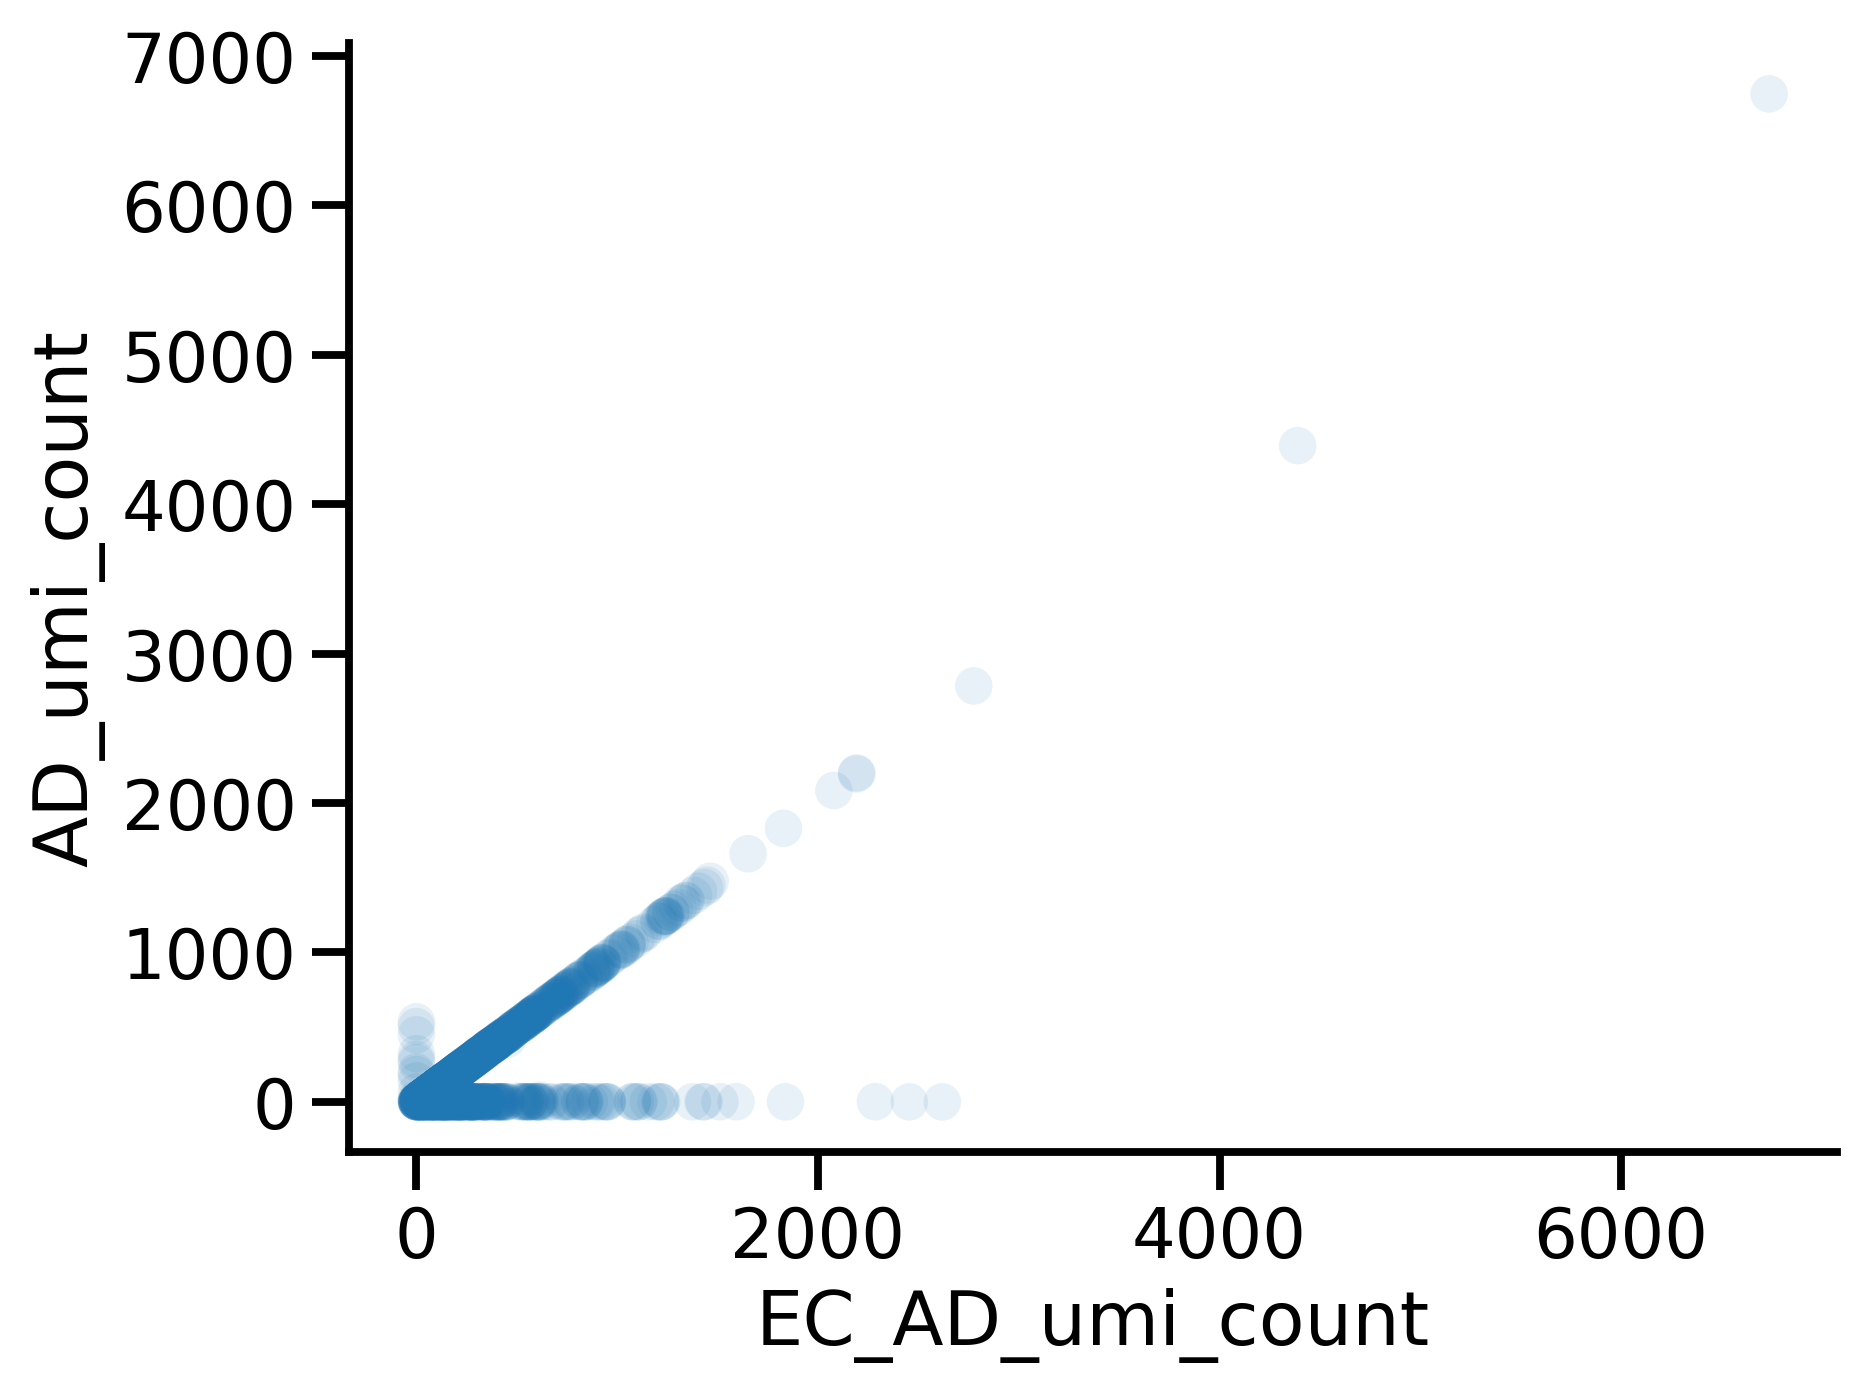

In [44]:
# For some reason my UMI count is lower, im missing some things
plt.figure(dpi = 300)
sns.set_context('talk')
ax = sns.scatterplot(data = merged_activities.sample(1000), x = "EC_AD_umi_count", y = "AD_umi_count", edgecolor = 'none', alpha = 0.1)
# ax.set_xscale('log')
# ax.set_yscale('log')
sns.despine()

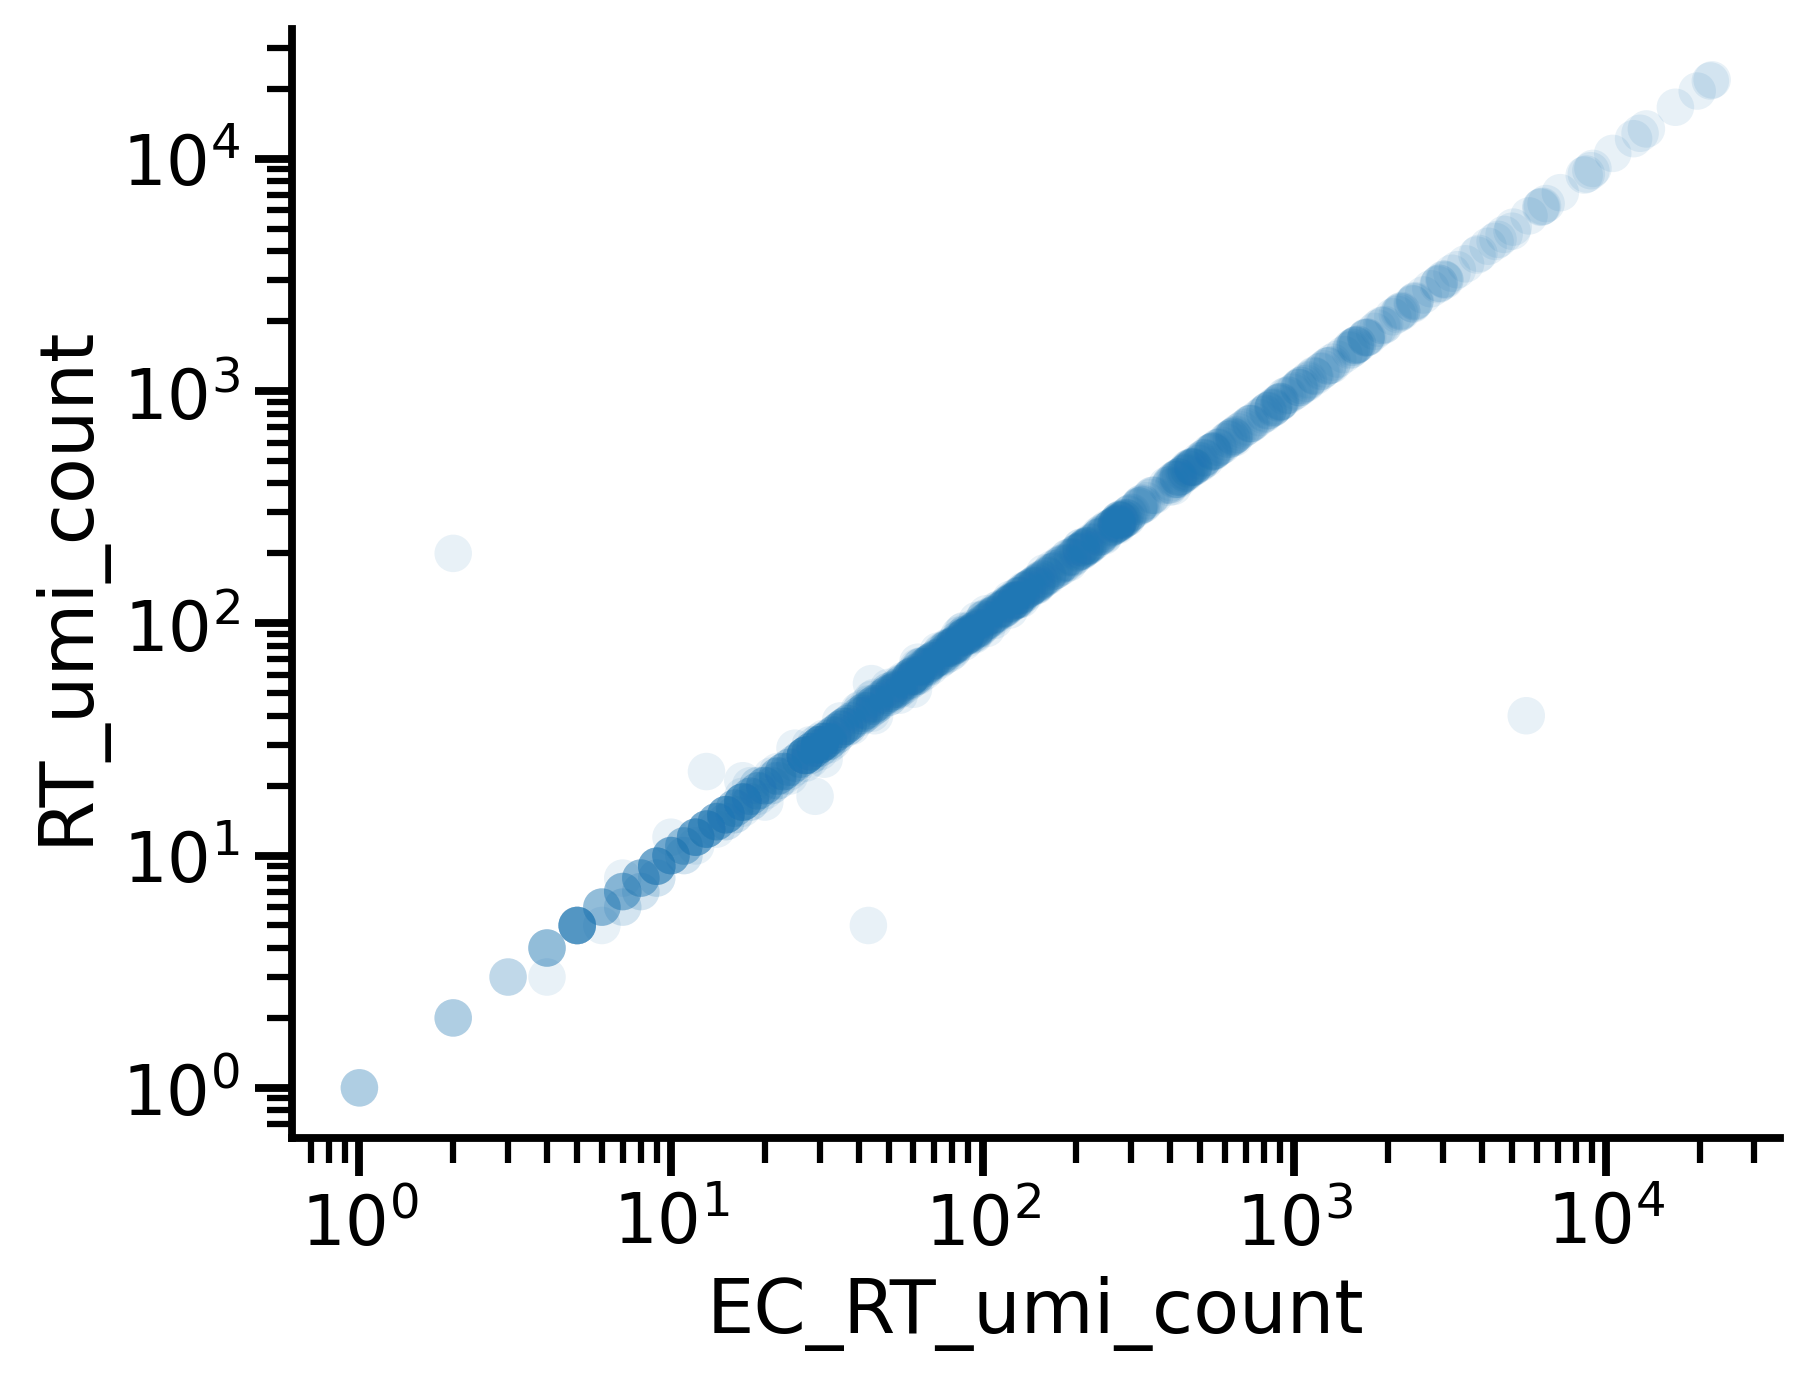

In [41]:
# My RT UMI count is well correlated
plt.figure(dpi = 300)
sns.set_context('talk')
ax = sns.scatterplot(data = merged_activities.sample(1000), x = "EC_RT_umi_count", y = "RT_umi_count", edgecolor = 'none', alpha = 0.1)
ax.set_xscale('log')
ax.set_yscale('log')
sns.despine()

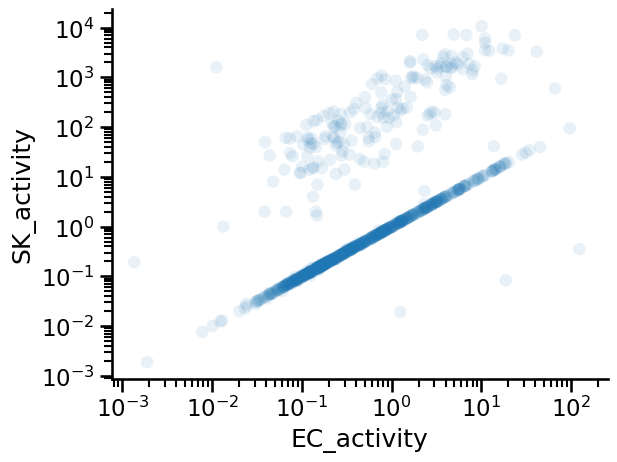

In [42]:
sns.set_context('talk')
ax = sns.scatterplot(data = merged_activities.sample(1000), x = "EC_activity", y = "SK_activity", edgecolor = 'none', alpha = 0.1)
ax.set_xscale('log')
ax.set_yscale('log')
sns.despine()